In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from joblib import load
import matplotlib.dates as mdates

# Paths
MODELS_DIR = Path("../../../data/out/best_models_ml/validation_ml/models")
PRED_DIR   = Path("../../../data/out/best_models_ml/validation_ml/predictions")
PLOTS_DIR  = Path("../../../data/out/best_models_ml/validation_ml/plots")
PLOTS_CUSTOM = Path("../../../data/out/best_models_ml/validation_ml/plots_custom")
PLOTS_CUSTOM.mkdir(parents=True, exist_ok=True)

C:\Users\Camilo\AppData\Local\Temp\ipykernel_25916\585166503.py:34: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  fechas = pd.date_range(start="2025-07-01 00:00", periods=n, freq="H")


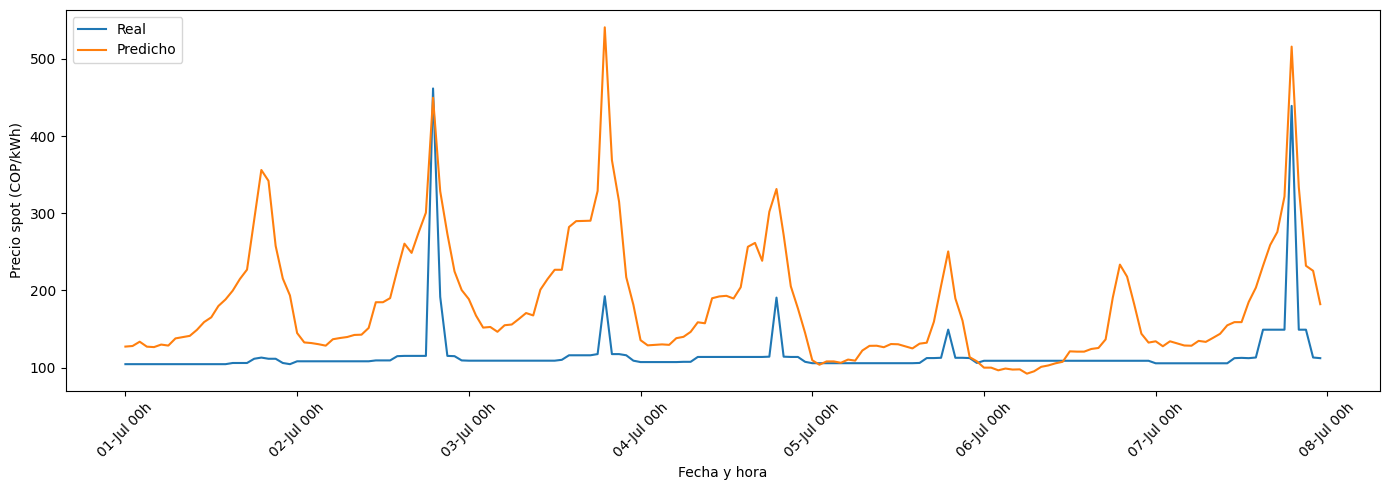

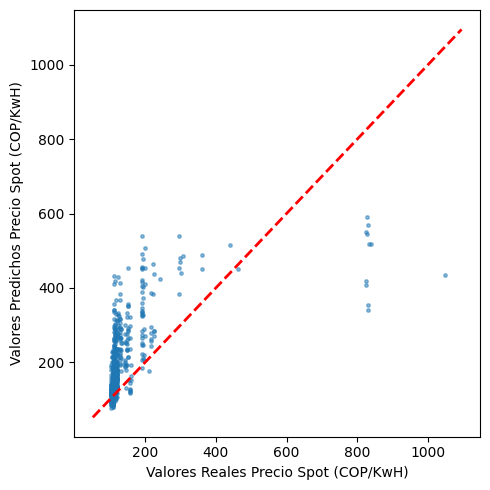

C:\Users\Camilo\AppData\Local\Temp\ipykernel_25916\585166503.py:69: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  fechas = pd.date_range(start="2025-07-01 00:00", periods=n, freq="H")


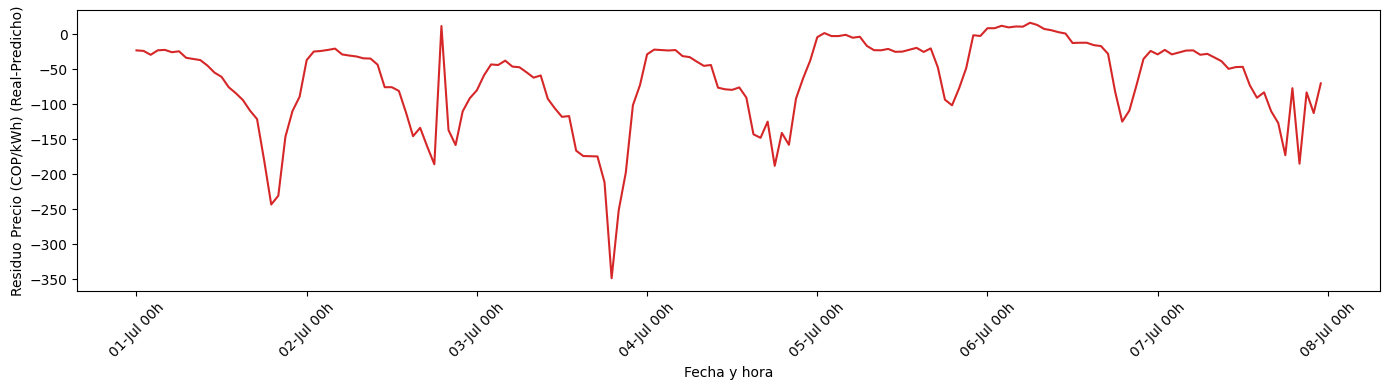

In [ ]:
variant = "v8_only_gen_no_solar_enso_lags"
config_name = "XGBoost"

# Dataset de validación externo
df_val = pd.read_csv("../../../data/out/dataset_validation_final.csv")
X_val = df_val.drop(columns=["PRECIO", "FECHA_HORA"])
y_val = df_val["PRECIO"]

# Cargar un modelo específico
model_file = MODELS_DIR / "v8_only_gen_no_solar_enso_lags_XGBoost.joblib"
pipe = load(model_file)

# Predecir
y_pred = pipe.predict(X_val)

# ----------------------------------------------------------------------
n = len(y_val)
n_observations = 24 * 7 # 7 días de observaciones

# Crear un rango de fechas-horas manual
fechas = pd.date_range(start="2025-07-01 00:00", periods=n, freq="H")

# 1. Predicciones vs reales
plt.figure(figsize=(14,5))
plt.plot(fechas[:n_observations], y_val.values[:n_observations], label="Real")
plt.plot(fechas[:n_observations], y_pred[:n_observations], label="Predicho")
plt.xlabel("Fecha y hora")
plt.ylabel("Precio spot (COP/kWh)")
plt.legend()
# Formato de eje X: día-mes hora
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%d-%b %Hh"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(PLOTS_CUSTOM / f"pred_{variant}_{config_name}.png")
plt.show()
plt.close()


# 2. Scatter con línea y=x
plt.figure(figsize=(5,5))
plt.scatter(y_val, y_pred, s=6, alpha=0.5)
lims = [min(plt.xlim()[0], plt.ylim()[0]), max(plt.xlim()[1], plt.ylim()[1])]
plt.plot(lims, lims, 'r--', linewidth=2)
plt.xlabel("Valores Reales Precio Spot (COP/KwH)")
plt.ylabel("Valores Predichos Precio Spot (COP/KwH)")
plt.tight_layout()
plt.savefig(PLOTS_CUSTOM / f"scatter_{variant}_{config_name}.png")
plt.show()
plt.close()


# 3. Residuos
# --- Gráfico de residuos ---
resid = y_val - y_pred
n = len(resid)
fechas = pd.date_range(start="2025-07-01 00:00", periods=n, freq="H")


# Construir eje temporal manual (1 de julio 2025, cada hora)
plt.figure(figsize=(14,4))
plt.plot(fechas[:n_observations], resid[:n_observations], color="tab:red")
plt.xlabel("Fecha y hora")
plt.ylabel("Residuo Precio (COP/kWh) (Real-Predicho)")
#plt.title("Errores de predicción por hora")

# Formato de eje X: día-mes hora
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%d-%b %Hh"))
#plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=24))  # ticks cada 24 horas
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(PLOTS_CUSTOM / f"resid_{variant}_{config_name}.png")
plt.show()
plt.close()

